In [1]:
!pip install pandas
!pip install numpy
!pip install tensorflow



In [2]:
import pandas as pd
import numpy as np
import tensorflow as tf

I0000 00:00:1773019871.070535   98494 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1773019871.113266   98494 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1773019872.254723   98494 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [3]:
a11=np.random.random(62500)*40-20
a12=np.random.random(62500)*40-20
a21=np.random.random(62500)*40-20
a22=np.random.random(62500)*40-20

b11=np.random.random(62500)*40-20
b12=np.random.random(62500)*40-20
b21=np.random.random(62500)*40-20
b22=np.random.random(62500)*40-20


df=pd.DataFrame({   'a11':a11,
                    'a12':a12,
                    'a21':a21,
                    'a22':a22,
                    'b11':b11,
                    'b12':b12,
                    'b21':b21,
                    'b22':b22,
                    })

print(len(df),len(df.drop_duplicates()))

df['R11']=(df['a11']*df['b11'])+(df['a12']*df['b21'])
df['R12']=(df['a11']*df['b12'])+(df['a12']*df['b22'])
df['R21']=(df['a21']*df['b11'])+(df['a22']*df['b21'])
df['R22']=(df['a21']*df['b12'])+(df['a22']*df['b22'])

df.head()

62500 62500


,a11,a12,a21,a22,b11,b12,b21,b22,R11,R12,R21,R22
0,4.023724,0.303993,8.094183,-0.023433,19.631231,18.146718,8.848189,19.378447,81.680437,78.908294,158.691436,146.428754
1,16.077128,-1.769488,-8.445043,13.848464,-4.519777,11.511359,12.632459,-7.532843,-95.018019,198.398868,213.109876,-201.532236
2,18.063965,-17.716109,-10.341661,-17.696860,18.585388,4.532044,-13.698682,16.892807,578.413129,-217.408139,50.219872,-345.818505
3,6.007431,-12.887787,-3.191068,19.297479,-9.505511,6.947574,-11.153273,11.864277,86.637292,-111.167197,-184.897311,206.780453
4,19.765620,-9.384672,-3.451871,19.010555,4.230728,-16.042084,14.652834,-19.013305,-53.889084,-138.648088,263.954584,-306.078284


In [4]:
df_train=df[:50000]
df_test=df[50000:]

print(len(df_train), len(df_test))

50000 12500


In [5]:
print(df.columns)

Index(['a11', 'a12', 'a21', 'a22', 'b11', 'b12', 'b21', 'b22', 'R11', 'R12',
       'R21', 'R22'],
      dtype='str')


In [6]:
salidas=['R11','R12','R21','R22']
entradas=['a11', 'a12', 'a21', 'a22', 'b11', 'b12', 'b21', 'b22']
tamaño=len(entradas)

x=[]

for i in entradas:
    x.append(df_train[i])

X=np.column_stack(x)

y=[]

for i in salidas:
    y.append(df_train[i])

Y=np.column_stack(y)

entrada = tf.keras.layers.Dense(units=tamaño, input_shape=[tamaño], activation="relu")
c1 = tf.keras.layers.Dense(units=128, activation="relu")
c2 = tf.keras.layers.Dense(units=128, activation="relu")
c3 = tf.keras.layers.Dense(units=128, activation="relu")
c4 = tf.keras.layers.Dense(units=128, activation="relu")
salida = tf.keras.layers.Dense(units=4, activation="linear")
red = tf.keras.Sequential([entrada, c1, c2,c3,c4, salida])
#red = tf.keras.Sequential([entrada, c1, c2,c3,c4, c5,c6, salida])
red.compile(optimizer='adam',
            loss="mse",
            metrics=['accuracy'])

/home/robotica/Jupyter_lab/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1773019875.227515   98494 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


In [7]:
historial = red.fit(X, Y, epochs=200, verbose=False)

In [13]:
def clasificar_dataframe(df, modelo, columnas, salidas):
    X = df[columnas].values
    preds = modelo.predict(X)

    for i in range(len(salidas)):
        df[salidas[i]] = preds[:,i]
#    df['R11_a'] = preds[:,0]
    #df['Predeccion']=(preds > 0.5).astype(int)
    return df

salidas_2 = []
errores= []
for i in salidas:
    salidas_2.append(f'{i}_pred')
    errores.append(f'{i}_error')

clasificar_dataframe(df_test, red, entradas, salidas_2)

391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 765us/step


,a11,a12,a21,a22,b11,b12,b21,b22,R11,R12,...,R22,R11_pred,R12_pred,R21_pred,R22_pred,R11_error,R12_error,R21_error,R22_error,error_media
50000,-8.707520,12.730733,-12.312044,2.694818,-0.150709,-19.609877,-18.738528,1.483413,-237.242897,189.638340,...,245.435193,-226.603806,182.454788,-53.293571,248.687119,4.484472,3.788027,9.564244,1.324963,4.790427
50001,4.180139,-8.798607,-2.828136,7.142854,-15.985577,-8.332820,9.163472,1.995277,-147.447725,-52.388004,...,37.818318,-139.858139,-45.760612,99.311394,33.520489,5.147307,12.650590,10.257592,11.364412,9.854975
50002,-0.988192,-10.664194,-7.963508,-10.563606,-13.016839,17.828424,-17.159819,-8.008987,195.858784,67.791483,...,-57.373026,187.831650,64.245026,284.576019,-53.472511,4.098430,5.231421,0.123978,6.798516,4.063086
50003,2.601735,-0.926782,-0.810141,1.449949,-19.456543,-10.635263,13.156829,16.916135,-62.814275,-43.347701,...,33.143602,-56.107224,-46.154064,21.111284,35.992432,10.677591,6.474076,39.403788,8.595415,16.287718
50004,-4.481104,-2.164119,-9.943760,-6.869610,5.497211,9.979749,-12.504370,14.280275,2.427375,-75.624515,...,-197.336157,9.205490,-69.566452,27.045088,-194.410614,279.236428,8.010713,13.420261,1.482517,75.537480
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62495,5.428730,-17.122166,0.292134,16.979488,19.374420,-19.435848,-0.181865,-15.629985,108.292434,162.107219,...,-271.067025,100.944038,163.308670,-0.172137,-253.556885,6.785697,0.741146,106.692858,6.459709,30.169852
62496,15.659024,5.561004,-15.412568,0.111731,0.790527,-2.835428,4.853377,10.415372,39.368530,13.519890,...,44.864949,40.332211,13.461647,-19.822668,46.231216,2.447846,0.430796,70.271818,3.045289,19.048937
62497,13.841924,0.866496,-17.893780,-11.856804,-7.226215,-19.315132,16.889530,2.601228,-85.390003,-265.104629,...,314.778463,-78.848183,-262.897766,-73.050972,310.334656,7.661108,0.832450,2.958955,1.411725,3.216059
62498,15.575182,-5.381436,-8.659031,3.069476,14.695122,-16.085011,-9.700720,-6.629494,281.083012,-214.850787,...,118.931540,275.365967,-216.140640,-155.002731,117.499283,2.033935,0.600349,1.285759,1.204270,1.281078


In [14]:
for i in zip(salidas, salidas_2, errores):
    df_test[i[2]]=np.abs((df_test[i[0]]-df_test[i[1]])/df_test[i[0]])*100
    print(i)

df_test['error_media'] = df_test[errores].mean(axis=1)

print(df_test['error_media'].mean())
print(salidas+salidas_2+errores+['error_media'])
df_test[salidas+salidas_2+errores+['error_media']].sort_values(by='error_media', ascending=False).head(100)

('R11', 'R11_pred', 'R11_error')
('R12', 'R12_pred', 'R12_error')
('R21', 'R21_pred', 'R21_error')
('R22', 'R22_pred', 'R22_error')
22.260269704248604
['R11', 'R12', 'R21', 'R22', 'R11_pred', 'R12_pred', 'R21_pred', 'R22_pred', 'R11_error', 'R12_error', 'R21_error', 'R22_error', 'error_media']


,R11,R12,R21,R22,R11_pred,R12_pred,R21_pred,R22_pred,R11_error,R12_error,R21_error,R22_error,error_media
50156,76.102496,0.027562,-497.646942,315.424959,91.107254,-20.620659,-487.766510,307.879974,19.716512,74915.969919,1.985430,2.392006,18735.015967
53579,-0.986029,0.045463,333.867220,264.416257,-0.560793,-12.032756,335.074860,259.750824,43.126115,26567.329418,0.361713,1.764427,6653.145418
50526,-0.025597,13.520706,351.016746,-141.274670,-6.217497,10.401514,344.732819,-144.186813,24189.809575,23.069742,1.790207,2.061334,6054.182715
50767,-414.608912,0.062154,162.129396,115.463279,-399.624603,13.892860,146.056534,114.267624,3.614083,22252.166122,9.913601,1.035529,5566.682334
59675,153.692111,10.823025,-0.048317,164.808490,145.243729,4.639752,-8.933721,163.801361,5.496953,57.130731,18389.768065,0.611090,4613.251709
...,...,...,...,...,...,...,...,...,...,...,...,...,...
58727,-2.377787,-204.631875,1.150393,179.780618,7.833333,-201.898666,-7.106377,175.763657,429.438004,1.335671,717.734971,2.234368,287.685753
56631,74.087445,97.816056,24.018421,-0.093088,72.404488,96.557274,24.558897,-1.146358,2.271582,1.286887,2.250256,1131.472898,284.320406
61232,39.519907,147.550206,-1.044930,126.073114,41.216824,144.434921,-12.709114,119.725800,4.293828,2.111339,1116.264960,5.034629,281.926189
58255,-0.767462,-251.702539,-1.623029,-208.363412,6.628046,-242.578140,-4.067545,-202.392838,963.632293,3.625072,150.614470,2.865462,280.184324


In [10]:
!pip install seaborn

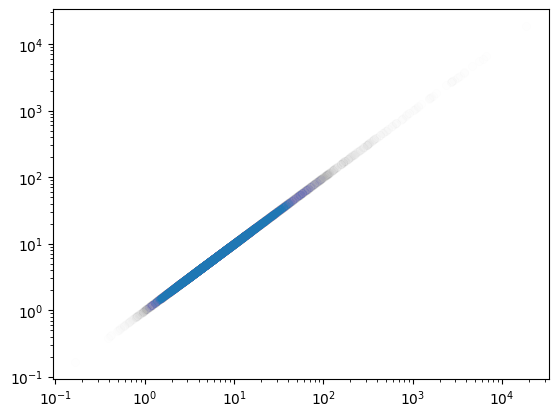

In [15]:
import matplotlib.pyplot as plt

plt.xscale('log')
plt.yscale('log')
plt.scatter(df_test['error_media'], df_test['error_media'], alpha=0.002)


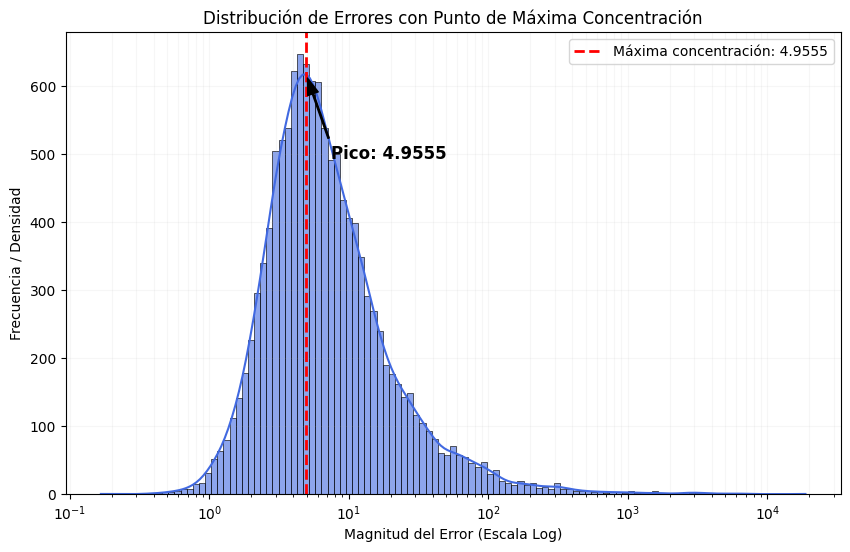

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 6))

# 1. Crear el gráfico y guardar el objeto 'ax' para extraer datos
ax = sns.histplot(df_test['error_media'], kde=True, log_scale=True, color='royalblue', alpha=0.6)

# 2. Extraer los datos de la curva KDE (la línea suavizada)
line = ax.lines[0]
x, y = line.get_data()

# 3. Encontrar el valor de X donde la Y es máxima (el pico de concentración)
idx_max = np.argmax(y)
pico_error = x[idx_max]

# 4. Añadir la indicación visual (línea vertical)
plt.axvline(pico_error, color='red', linestyle='--', lw=2, label=f'Máxima concentración: {pico_error:.4f}')

# 5. Añadir un texto explicativo sobre el pico
plt.annotate(f'Pico: {pico_error:.4f}', 
             xy=(pico_error, y[idx_max]), 
             xytext=(pico_error * 1.5, y[idx_max] * 0.8), # Ajustamos posición del texto
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8),
             fontsize=12, fontweight='bold')

plt.title('Distribución de Errores con Punto de Máxima Concentración')
plt.xlabel('Magnitud del Error (Escala Log)')
plt.ylabel('Frecuencia / Densidad')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.1)
plt.show()